 ## Классификация

Загружаем датасеты в память

In [2]:
import os
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/content")
cls_path = DATA_DIR / "car_evaluation.csv"
REG_PATH = DATA_DIR / "CarPrice_Assignment.csv"
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
def load_car_evaluation(path):
    df = pd.read_csv(path, header=None, names=col_names, dtype=str)
    for c in df.columns:
        df[c] = df[c].str.strip().str.lower()
    return df

df_cls = load_car_evaluation(cls_path)
print(df_cls.head(5))
print("Shape:", df_cls.shape)
print("Target distribution:\n", df_cls['class'].value_counts())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Shape: (1728, 7)
Target distribution:
 class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [3]:
X_cls = df_cls.drop(columns=['class'])
y_cls = df_cls['class']
print("Class proportions:\n", y_cls.value_counts(normalize=True))

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)
print("Train size:", X_train_cls.shape, "| Test size:", X_test_cls.shape)


Class proportions:
 class
unacc    0.700231
acc      0.222222
good     0.039931
vgood    0.037616
Name: proportion, dtype: float64
Train size: (1382, 6) | Test size: (346, 6)


Логистическая регрессия подходит лучше для задачи классификация

Baseline: LR (lbfgs, L2)
Accuracy: 0.9017 | F1-macro: 0.7873

              precision    recall  f1-score   support

         acc     0.7722    0.7922    0.7821        77
        good     0.6364    0.5000    0.5600        14
       unacc     0.9588    0.9628    0.9608       242
       vgood     0.8462    0.8462    0.8462        13

    accuracy                         0.9017       346
   macro avg     0.8034    0.7753    0.7873       346
weighted avg     0.9000    0.9017    0.9005       346



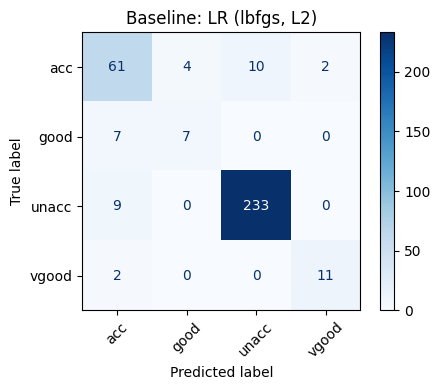

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

cat_cols = list(X_train_cls.columns)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

def eval_and_report(model, X_test, y_test, title=""):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    print(f"{title}\nAccuracy: {acc:.4f} | F1-macro: {f1m:.4f}\n")
    print(classification_report(y_test, y_pred, digits=4))
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, xticks_rotation=45, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return acc, f1m

baseline = Pipeline([
    ("prep", ColumnTransformer([
        ("ohe", ohe, cat_cols),
    ], remainder="drop")),
    ("clf", LogisticRegression(
        multi_class="auto", solver="lbfgs", max_iter=2000, n_jobs=None, random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train_cls, y_train_cls)
base_acc, base_f1 = eval_and_report(baseline, X_test_cls, y_test_cls, title="Baseline: LR (lbfgs, L2)")


Найдем оптимиальные параметры гридсерчем

Best params: {'clf__C': 10.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
CV best F1-macro: 0.8768662358620685
Improved #1: GridSearch LR
Accuracy: 0.9393 | F1-macro: 0.8981

              precision    recall  f1-score   support

         acc     0.8415    0.8961    0.8679        77
        good     0.7000    1.0000    0.8235        14
       unacc     1.0000    0.9463    0.9724       242
       vgood     0.8667    1.0000    0.9286        13

    accuracy                         0.9393       346
   macro avg     0.8520    0.9606    0.8981       346
weighted avg     0.9476    0.9393    0.9415       346



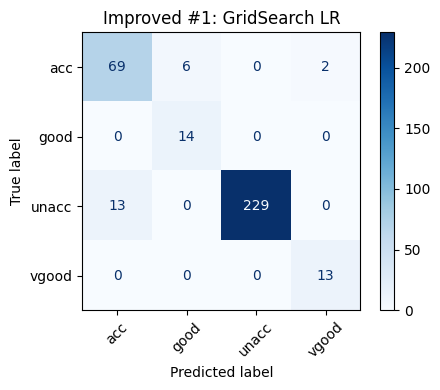

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe = Pipeline([
    ("prep", ColumnTransformer([("ohe", ohe, cat_cols)], remainder="drop")),
    ("clf", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

param_grid = [
    {
        "clf__solver": ["lbfgs", "saga"],
        "clf__penalty": ["l2"],
        "clf__C": [0.05, 0.1, 0.5, 1.0, 3.0, 10.0],
        "clf__class_weight": [None, "balanced"]
    },
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["l1"],
        "clf__C": [0.05, 0.1, 0.5, 1.0, 3.0],
        "clf__class_weight": [None, "balanced"]
    },
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["elasticnet"],
        "clf__l1_ratio": [0.2, 0.5, 0.8],
        "clf__C": [0.1, 0.5, 1.0, 3.0],
        "clf__class_weight": [None, "balanced"]
    },
]

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_cls, y_train_cls)

print("Best params:", grid.best_params_)
print("CV best F1-macro:", grid.best_score_)
gs_acc, gs_f1 = eval_and_report(grid.best_estimator_, X_test_cls, y_test_cls, title="Improved #1: GridSearch LR")


## Реализация алгоритма логистической регрессии

In [24]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from scipy import sparse

cat_cols = list(X_train_cls.columns)

ohe_custom = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
Xtr = ohe_custom.fit_transform(X_train_cls[cat_cols])
Xte = ohe_custom.transform(X_test_cls[cat_cols])

classes_, ytr = np.unique(y_train_cls, return_inverse=True)
yte = np.searchsorted(classes_, y_test_cls.values)


Я предпочел реализовать оптимизатор первого порядка, так как это проще и должно подходить под все датасеты, а не только мой

In [19]:
import numpy as np
from scipy import sparse

class MyLogisticRegressionAdam:
    def __init__(self, C=10.0, lr=0.02, batch_size=512, max_epochs=200,
                 beta1=0.9, beta2=0.999, eps=1e-8,
                 class_weight="balanced", val_fraction=0.15,
                 patience=15, tol=1e-4, random_state=42, verbose=False):
        self.C=C; self.lr=lr; self.batch_size=batch_size; self.max_epochs=max_epochs
        self.beta1=beta1; self.beta2=beta2; self.eps=eps
        self.class_weight=class_weight; self.val_fraction=val_fraction
        self.patience=patience; self.tol=tol; self.random_state=random_state; self.verbose=verbose
        self.W=None; self.b=None
        self.history_ = {}

    @staticmethod
    def _softmax(Z):
        Zm = Z - Z.max(axis=1, keepdims=True)
        np.exp(Zm, out=Zm)
        Zm /= Zm.sum(axis=1, keepdims=True)
        return Zm

    def _compute_class_weights(self, y, K):
        if self.class_weight is None:
            return np.ones(K, float)
        if self.class_weight == "balanced":
            n = y.shape[0]
            cnt = np.bincount(y, minlength=K).astype(float)
            return n / (K * np.maximum(cnt, 1.0))
        if isinstance(self.class_weight, dict):
            cw = np.ones(K, float)
            for k,v in self.class_weight.items():
                cw[int(k)] = float(v)
            return cw
        raise ValueError("Unsupported class_weight")

    def _loss_and_grad(self, X, y, W, b, lam):
        n, D = X.shape
        K = b.shape[0]

        logits = X.dot(W) + b
        P = self._softmax(logits)

        cw = self._compute_class_weights(y, K)
        samp_w = cw[y]
        w_sum = samp_w.sum()

        p_true = np.clip(P[np.arange(n), y], 1e-15, 1.0)
        nll = -np.sum(samp_w * np.log(p_true)) / w_sum

        l2 = 0.5 * lam * np.sum(W*W)
        loss = nll + l2

        G = P.copy()
        G[np.arange(n), y] -= 1.0
        G *= (samp_w / w_sum)[:, None]

        if sparse.issparse(X):
            dW = X.T.dot(G) + lam * W
        else:
            dW = X.T @ G + lam * W
        db = G.sum(axis=0)
        return loss, dW, db

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = X.tocsr() if sparse.issparse(X) else X
        n, D = X.shape
        K = int(np.max(y))+1
        lam = 1.0/self.C

        self.W = rng.normal(0, 0.01, size=(D,K))
        self.b = np.zeros(K, float)

        # простой val split
        idx = np.arange(n); rng.shuffle(idx)
        val_sz = max(1, int(self.val_fraction * n))
        val_idx, tr_idx = idx[:val_sz], idx[val_sz:]
        Xtr, ytr = X[tr_idx], y[tr_idx]
        Xval, yval = X[val_idx], y[val_idx]

        mW = np.zeros_like(self.W); vW = np.zeros_like(self.W)
        mb = np.zeros_like(self.b); vb = np.zeros_like(self.b)

        best_loss = np.inf
        best_W = self.W.copy(); best_b = self.b.copy()
        patience_left = self.patience
        t = 0

        train_losses=[]; val_losses=[]

        for epoch in range(1, self.max_epochs+1):
            perm = rng.permutation(Xtr.shape[0])
            for start in range(0, Xtr.shape[0], self.batch_size):
                batch = perm[start:start+self.batch_size]
                Xb, yb = Xtr[batch], ytr[batch]
                t += 1

                loss, dW, db = self._loss_and_grad(Xb, yb, self.W, self.b, lam)

                # Adam
                mW = self.beta1*mW + (1-self.beta1)*dW
                vW = self.beta2*vW + (1-self.beta2)*(dW*dW)
                mb = self.beta1*mb + (1-self.beta1)*db
                vb = self.beta2*vb + (1-self.beta2)*(db*db)

                mW_hat = mW/(1-self.beta1**t); vW_hat = vW/(1-self.beta2**t)
                mb_hat = mb/(1-self.beta1**t); vb_hat = vb/(1-self.beta2**t)

                self.W -= self.lr * mW_hat/(np.sqrt(vW_hat)+self.eps)
                self.b -= self.lr * mb_hat/(np.sqrt(vb_hat)+self.eps)

            tr_loss, _, _ = self._loss_and_grad(Xtr, ytr, self.W, self.b, lam)
            vl_loss, _, _ = self._loss_and_grad(Xval, yval, self.W, self.b, lam)
            train_losses.append(tr_loss); val_losses.append(vl_loss)
            if self.verbose:
                print(f"epoch {epoch:03d} | train {tr_loss:.5f} | val {vl_loss:.5f}")

            improved = vl_loss + self.tol < best_loss
            if improved:
                best_loss = vl_loss
                best_W = self.W.copy(); best_b = self.b.copy()
                patience_left = self.patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    if self.verbose:
                        print("Early stopping")
                    break

        self.W, self.b = best_W, best_b
        self.history_ = {"train_loss": np.array(train_losses),
                         "val_loss": np.array(val_losses)}
        return self

    def predict_proba(self, X):
        X = X.tocsr() if sparse.issparse(X) else X
        logits = X.dot(self.W) + self.b
        return self._softmax(logits)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


Обучим логистический регрессор

epoch 001 | train 1.27984 | val 1.28941
epoch 002 | train 1.20869 | val 1.23389
epoch 003 | train 1.16144 | val 1.19891
epoch 004 | train 1.13375 | val 1.17781
epoch 005 | train 1.11917 | val 1.16737
epoch 006 | train 1.11219 | val 1.16165
epoch 007 | train 1.10830 | val 1.15908
epoch 008 | train 1.10499 | val 1.15405
epoch 009 | train 1.10145 | val 1.14579
epoch 010 | train 1.09878 | val 1.13864
epoch 011 | train 1.09649 | val 1.13276
epoch 012 | train 1.09458 | val 1.12505
epoch 013 | train 1.09355 | val 1.11880
epoch 014 | train 1.09295 | val 1.11594
epoch 015 | train 1.09298 | val 1.11644
epoch 016 | train 1.09277 | val 1.11580
epoch 017 | train 1.09248 | val 1.11412
epoch 018 | train 1.09237 | val 1.11411
epoch 019 | train 1.09270 | val 1.11504
epoch 020 | train 1.09303 | val 1.11658
epoch 021 | train 1.09351 | val 1.11652
epoch 022 | train 1.09334 | val 1.11801
epoch 023 | train 1.09259 | val 1.12174
epoch 024 | train 1.09234 | val 1.12817
epoch 025 | train 1.09236 | val 1.13087


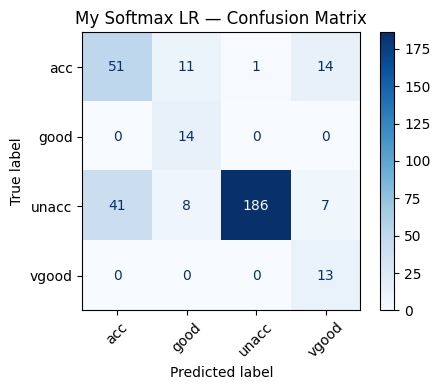

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

my_lr = MyLogisticRegressionAdam(
    C=10.0, class_weight="balanced",
    lr=0.02, batch_size=512, max_epochs=300,
    patience=20, tol=1e-4, random_state=42, verbose=True
).fit(Xtr, ytr)

yhat_my = my_lr.predict(Xte)
acc_my  = accuracy_score(yte, yhat_my)
f1m_my  = f1_score(yte, yhat_my, average="macro")
print(f"My LR (Adam) | Accuracy: {acc_my:.4f} | F1-macro: {f1m_my:.4f}")

print("\nClassification report (my):\n",
      classification_report(yte, yhat_my, target_names=classes_, digits=4))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test_cls, classes_[yhat_my], ax=ax, xticks_rotation=45, cmap="Blues")
ax.set_title("My Softmax LR — Confusion Matrix")
plt.tight_layout(); plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

sk_lr = LogisticRegression(
    C=10.0, penalty="l2", solver="lbfgs", class_weight="balanced",
    max_iter=4000, random_state=42
).fit(Xtr, ytr)
sk_pred = sk_lr.predict(Xte)

cmp_df = pd.DataFrame([
    ["sklearn LR", accuracy_score(yte, sk_pred), f1_score(yte, sk_pred, average="macro")],
    ["my LR (Adam)", acc_my, f1m_my],
], columns=["Model","Accuracy","F1-macro"])
cmp_df


,Model,Accuracy,F1-macro
0,sklearn LR,0.939306,0.898106
1,my LR (Adam),0.763006,0.654905


Ожидаемо моя регрессия показала результат хуже, потому что в библиотечной модели я использую метод второго порядка, а тут первого

# Регрессия

In [28]:
from sklearn.preprocessing import MinMaxScaler

def load_car_price_assignment(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    y = df["price"]
    X = df.drop(columns=["price", "car_ID"])
    # Выделяем бренд из имени модели
    if "CarName" in X.columns:
        carnames = X["CarName"].astype(str).str.strip().str.lower()
        X["brand"] = carnames.str.split("[ \-]", n=1, expand=True)[0]
        X = X.drop(columns=["CarName"])
    # Конвертация слов-чисел в числа (doornumber, cylindernumber)
    NUM_WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
    for col in ["doornumber", "cylindernumber"]:
        if col in X.columns and X[col].dtype == object:
            X[col] = X[col].str.strip().str.lower().map(NUM_WORDS).astype("Int64")
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype(str).str.strip().str.lower()
    return X, y

X_reg_raw, y_reg_raw = load_car_price_assignment(REG_PATH)
print("Regression dataset shape:", X_reg_raw.shape, "| target shape:", y_reg_raw.shape)
print("Sample columns:", list(X_reg_raw.columns)[:10], "...")
print("Target name:", y_reg_raw.name)


Regression dataset shape: (205, 24) | target shape: (205,)
Sample columns: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth'] ...
Target name: price


Разделим на трейн и тест, а также выведем признаки

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.2, random_state=RANDOM_STATE
)

cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == object]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

cat_cols_reg[:5], num_cols_reg[:5], len(cat_cols_reg), len(num_cols_reg)


(['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation'],
 ['symboling', 'doornumber', 'wheelbase', 'carlength', 'carwidth'],
 8,
 16)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), num_cols_reg),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_cols_reg),
    ],
    remainder="drop"
)


Обучение бейзлайна

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

baseline_reg = Pipeline([
    ("prep", preprocess_reg),
    ("lr", LinearRegression())
])

baseline_reg.fit(X_train_reg, y_train_reg)
y_pred_base = baseline_reg.predict(X_test_reg)

def eval_reg(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{name}\nRMSE={rmse:.2f} | MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.4f}\n")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MSE": mse, "R2": r2}

scores = []
scores.append(eval_reg(y_test_reg, y_pred_base, "Baseline: OLS LinearRegression"))


Baseline: OLS LinearRegression
RMSE=2864.02 | MAE=1935.11 | MSE=8202621.82 | R²=0.8961



Обучение улучшенного бейзлайна

In [33]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.compose import TransformedTargetRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def fit_ttr(model, name):
    pipe = Pipeline([
        ("prep", preprocess_reg),
        ("reg", TransformedTargetRegressor(
            regressor=model,
            func=np.log1p, inverse_func=np.expm1
        ))
    ])
    pipe.fit(X_train_reg, y_train_reg)
    pred = pipe.predict(X_test_reg)
    scores.append(eval_reg(y_test_reg, pred, name))
    return pipe

ridge_grid = GridSearchCV(
    Pipeline([("prep", preprocess_reg),
              ("reg", TransformedTargetRegressor(
                  regressor=Ridge(random_state=RANDOM_STATE),
                  func=np.log1p, inverse_func=np.expm1))]),
    param_grid={"reg__regressor__alpha":[0.1, 0.3, 1.0, 3.0, 10.0, 30.0]},
    scoring="neg_mean_squared_error",
    cv=cv, n_jobs=-1
)
ridge_grid.fit(X_train_reg, y_train_reg)
ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test_reg)
scores.append(eval_reg(y_test_reg, ridge_pred, f"Ridge + log(y) (alpha={ridge_grid.best_params_['reg__regressor__alpha']})"))

lasso_grid = GridSearchCV(
    Pipeline([("prep", preprocess_reg),
              ("reg", TransformedTargetRegressor(
                  regressor=Lasso(random_state=RANDOM_STATE, max_iter=20000),
                  func=np.log1p, inverse_func=np.expm1))]),
    param_grid={"reg__regressor__alpha":[0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]},
    scoring="neg_mean_absolute_error",
    cv=cv, n_jobs=-1
)
lasso_grid.fit(X_train_reg, y_train_reg)
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test_reg)
scores.append(eval_reg(y_test_reg, lasso_pred, f"Lasso + log(y) (alpha={lasso_grid.best_params_['reg__regressor__alpha']})"))

enet_grid = GridSearchCV(
    Pipeline([("prep", preprocess_reg),
              ("reg", TransformedTargetRegressor(
                  regressor=ElasticNet(random_state=RANDOM_STATE, max_iter=20000),
                  func=np.log1p, inverse_func=np.expm1))]),
    param_grid={
        "reg__regressor__alpha":[0.0005, 0.001, 0.005, 0.01, 0.05],
        "reg__regressor__l1_ratio":[0.2, 0.5, 0.8]
    },
    scoring="neg_mean_squared_error",
    cv=cv, n_jobs=-1
)
enet_grid.fit(X_train_reg, y_train_reg)
enet_best = enet_grid.best_estimator_
enet_pred = enet_best.predict(X_test_reg)
scores.append(eval_reg(y_test_reg, enet_pred,
                       f"ElasticNet + log(y) (alpha={enet_grid.best_params_['reg__regressor__alpha']}, l1={enet_grid.best_params_['reg__regressor__l1_ratio']})"))


Ridge + log(y) (alpha=0.3)
RMSE=2286.83 | MAE=1596.56 | MSE=5229600.51 | R²=0.9338

Lasso + log(y) (alpha=0.001)
RMSE=1977.86 | MAE=1389.40 | MSE=3911943.45 | R²=0.9504

ElasticNet + log(y) (alpha=0.001, l1=0.2)
RMSE=2166.17 | MAE=1528.72 | MSE=4692291.91 | R²=0.9406



Графики

,Model,RMSE,MAE,MSE,R2
2,Lasso + log(y) (alpha=0.001),1977.863355,1389.399048,3.911943e+06,0.950447
3,"ElasticNet + log(y) (alpha=0.001, l1=0.2)",2166.169871,1528.724963,4.692292e+06,0.940562
1,Ridge + log(y) (alpha=0.3),2286.831982,1596.559078,5.229601e+06,0.933756
0,Baseline: OLS LinearRegression,2864.021966,1935.114263,8.202622e+06,0.896096


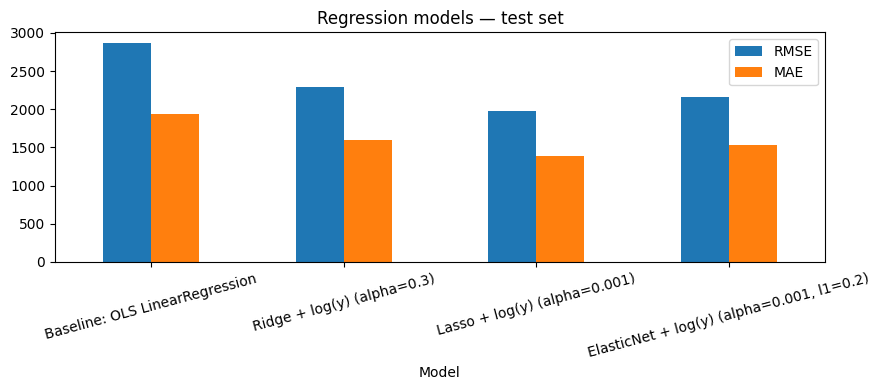

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

cmp = pd.DataFrame(scores)
display(cmp.sort_values("R2", ascending=False))

ax = cmp.set_index("Model")[["RMSE","MAE"]].plot(kind="bar", figsize=(9,4), rot=15)
ax.set_title("Regression models — test set")
ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()


Также для своей реализации повторим разделения

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from scipy import sparse
import numpy as np

cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == object]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), num_cols_reg),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_cols_reg),
    ],
    remainder="drop"
)

Xtr = preprocess_reg.fit_transform(X_train_reg, y_train_reg)
Xte = preprocess_reg.transform(X_test_reg)
Xtr.shape, Xte.shape


((164, 71), (41, 71))

Код модели

In [46]:
from scipy import sparse

def soft_threshold(x, lam):
    # S(x, lam) = sign(x) * max(|x|-lam, 0)
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)

class MyLassoRegressor:
    """
    Lasso: min (1/(2n))||y - Xw - b||^2 + alpha * ||w||_1
    - координатный спуск
    - X: CSR/CSC; внутренняя работа по столбцам (CSC)
    - b (intercept) не штрафуем
    """
    def __init__(self, alpha=0.001, max_iter=2000, tol=1e-5,
                 fit_intercept=True, warm_start=False, random_state=42, verbose=False):
        self.alpha = float(alpha)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.fit_intercept = bool(fit_intercept)
        self.warm_start = bool(warm_start)
        self.random_state = random_state
        self.verbose = verbose
        self.coef_ = None
        self.intercept_ = 0.0
        self.n_features_in_ = None

    def _prepare(self, X, y):
        if sparse.issparse(X):
            X_csr = X.tocsr()
            X_csc = X.tocsc()
        else:
            X_csr = sparse.csr_matrix(X)
            X_csc = sparse.csc_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        return X_csr, X_csc, y

    def fit(self, X, y):
        X_csr, X_csc, y = self._prepare(X, y)
        n, d = X_csr.shape
        self.n_features_in_ = d
        rng = np.random.default_rng(self.random_state)

        if (not self.warm_start) or (self.coef_ is None) or (len(self.coef_) != d):
            w = np.zeros(d, dtype=float)
            b = 0.0
        else:
            w = self.coef_.copy()
            b = float(self.intercept_)

        # удобная рабочая переменная: r = y - (Xw + b)
        r = y - (X_csr @ w + b)

        # предвычислим нормы столбцов: z_j = (1/n) * sum_i x_ij^2
        z = np.zeros(d, dtype=float)
        indptr = X_csc.indptr
        data = X_csc.data
        for j in range(d):
            start, end = indptr[j], indptr[j+1]
            col = data[start:end]
            z[j] = (col @ col) / n
        # чтобы избежать деления на 0
        z[z == 0.0] = 1e-12

        for it in range(1, self.max_iter + 1):
            max_delta = 0.0

            for j in range(d):
                start, end = indptr[j], indptr[j+1]
                rows = X_csc.indices[start:end]
                col  = data[start:end]

                if col.size == 0:
                    continue

                # текущий вклад столбца: r + x_j * w_j  (т.к. r = y - (Xw + b))
                # ρ_j = (1/n) * sum_i x_ij * (r_i + x_ij * w_j)
                rho = (col @ (r[rows] + col * w[j])) / n

                # обновление координаты (формула лассо)
                w_new = soft_threshold(rho, self.alpha) / z[j]
                if w_new == w[j]:
                    continue

                # обновляем резидуал: r := r - x_j * (w_new - w_old)
                diff = w_new - w[j]
                r[rows] -= col * diff
                max_delta = max(max_delta, abs(diff))
                w[j] = w_new

            # обновление смещения: b = mean(y - Xw)  => r := r - (b_new - b)
            if self.fit_intercept:
                b_new = r.mean() + b  # т.к. r = y - (Xw + b)
                r -= (b_new - b)
                max_delta = max(max_delta, abs(b_new - b))
                b = b_new

            if self.verbose and (it % 50 == 0 or it == 1):
                obj = 0.5 * np.mean(r * r) + self.alpha * np.sum(np.abs(w))
                print(f"iter {it:4d} | maxΔ={max_delta:.3e} | obj≈{obj:.6f}")

            if max_delta < self.tol:
                if self.verbose:
                    print(f"Converged at iter {it}, maxΔ={max_delta:.3e}")
                break

        self.coef_ = w
        self.intercept_ = b
        return self

    def predict(self, X):
      if not sparse.issparse(X):
          # dense
          y_hat = X @ self.coef_
      else:
          # sparse
          y_hat = X.dot(self.coef_)
      return np.asarray(y_hat).ravel() + self.intercept_



In [44]:
class LogTargetWrapper:
    def __init__(self, base_reg):
        self.base = base_reg
    def fit(self, X, y):
        self.base.fit(X, np.log1p(y))
        return self
    def predict(self, X):
        return np.expm1(self.base.predict(X))


Обучим свою модель

In [47]:
from sklearn.linear_model import Lasso
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_reg(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{name}\nRMSE={rmse:.2f} | MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.4f}\n")
    return rmse, mae, mse, r2

alpha = 0.001

my_lasso = LogTargetWrapper(
    MyLassoRegressor(alpha=alpha, max_iter=4000, tol=1e-6, fit_intercept=True, verbose=False)
).fit(Xtr, y_train_reg)
pred_my = my_lasso.predict(Xte)
eval_reg(y_test_reg, pred_my, f"My Lasso + log(y) (alpha={alpha})")

sk_lasso = TransformedTargetRegressor(
    regressor=Lasso(alpha=alpha, max_iter=40000, random_state=42),
    func=np.log1p, inverse_func=np.expm1
).fit(Xtr, y_train_reg)
pred_sk = sk_lasso.predict(Xte)
eval_reg(y_test_reg, pred_sk, f"sklearn Lasso + log(y) (alpha={alpha})")


My Lasso + log(y) (alpha=0.001)
RMSE=2432.85 | MAE=1698.34 | MSE=5918752.35 | R²=0.9250

sklearn Lasso + log(y) (alpha=0.001)
RMSE=1977.86 | MAE=1389.40 | MSE=3911943.45 | R²=0.9504



(np.float64(1977.8633553842644),
 1389.3990476396623,
 3911943.452571901,
 0.950446615095331)